<Axes: xlabel='Current density (A/cm$^2$)', ylabel='Cell voltage (V)'>

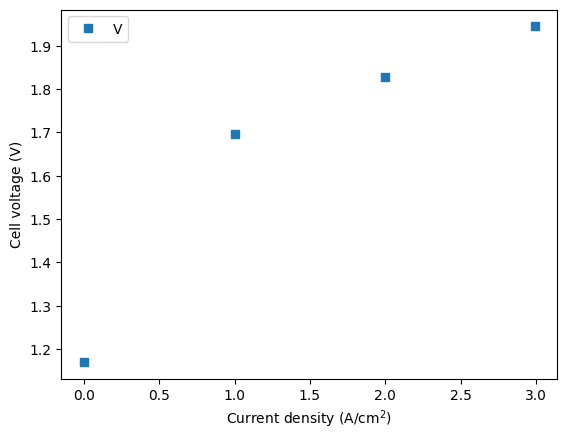

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import marapendi as mrpd

exp_data = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_fig1d.csv',sep=';',decimal=',')
exp_data_full = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_figS4_IrO2.csv',sep=';',decimal=',')
exp_data.plot(x='i', y='V', marker='s', linewidth=0, 
              ylabel='Cell voltage (V)', xlabel='Current density (A/cm$^2$)')



In [56]:
exp_data

,i,Erev,Ohmic,Act_ca,Act_an,Mass_ca,V
0,0.000000,1.1695,1.169500,1.169500,1.169500,1.169500,1.169500
1,1.000885,1.1695,1.222481,1.317934,1.639108,1.687617,1.696223
2,1.996572,1.1695,1.280899,1.388088,1.719432,1.807454,1.828968
3,2.993645,1.1695,1.338143,1.449242,1.788020,1.903033,1.944892


In [57]:


known_parameters = {
    'ca-cl-ionomer-to-carbon-ratio': 0.5, # Nominal value from Tricker et al. (2023)
    'ca-cl-pt-loading': 0.3e-2, # Nominal value from Tricker et al. (2023)
    'ca-cl-pt-wt': 0.468, # Nominal value from Tricker et al. (2023)
    'ca-gdl-thickness': 370e-6 * 0.8, #AvCarb MGL370 compressed at 20% (value given by Tricker et al.)
    'ca-gdl-porosity': 0.78 * 0.8, #AvCarb MGL370 compressed at 20% (value given by Tricker et al.)
    
    'an-ptl-thickness': 280e-6, # 11 mil according to Tricker et al. (2023)
    'an-ptl-porosity': 0.71, #Currento 10FP3 SS mesh value
    'an-ptl-ionomer-to-cat-ratio': 0.2, # Nominal value from Tricker et al. (2023)
    'an-catalyst-density': 11700., # IrO2
    'an-catalyst-loading': 0.8e-2, # Nominal value from Tricker et al. (2023)

    'memb-thickness': 30e-6, # Nominal value from Tricker et al. (2023)   
}

In [58]:
def create_electrolyzer(params):
    ec = mrpd.ElectrolyzerCell(
        cell_area=5e-4,  # Nominal value from Tricker et al. (2023)
        cell_number=1.,
        electrical_resistance=params['cell-electrical-resistance'],
        electrolyte_saturation_exponent=1,
        ca=mrpd.ElectrolyzerCellSide(
            cl=mrpd.PtCCatalystLayer(
                thickness=params['ca-cl-thickness'],
                ionomer_to_carbon_ratio=params['ca-cl-ionomer-to-carbon-ratio'], 
                carbon_agglomerate_radius=params['ca-cl-carbon-agg-radius'],
                platinum_loading=params['ca-cl-pt-loading'],     
                catalyst_platinum_weight_percent=params['ca-cl-pt-wt'],
                ecsa=params['ca-cl-ecsa'],
                ionomer=mrpd.PAPIonomer(),
                reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=params['her-i0-ref'],
                                                    activation_energy=params['her-act-energy'],
                                                    reaction_order=params['her-reaction-order'], 
                                                    reference_activity=1., 
                                                    number_of_electrons=2,
                                                    reference_temperature=353.15,charge_transfer_coeff=params['her-charge-transfer-coeff']),
                two_phase_transport_model=mrpd.DarcyTransportModel(params['J-function-exponent']),
                absolute_permeability=1.3e-13,
                contact_angle=85,
            ),
            gdl=mrpd.PorousLayer( #AvCarb MGL370 compressed at 20% (value given by Tricker et al.)
                thickness=params['ca-gdl-thickness'],  
                porosity=params['ca-gdl-porosity'],
                two_phase_transport_model=mrpd.DarcyTransportModel(params['J-function-exponent']),
                absolute_permeability=params['ca-gdl-permeability'],
                contact_angle=params['ca-gdl-contact-angle'],
            ),
            has_mpl=False
        ),
        an = mrpd.ElectrolyzerCellSide(
            cl=mrpd.PorousTransferLayer( 
                thickness=params['an-ptl-thickness'], 
                porosity=params['an-ptl-porosity'], 
                ionomer_to_catalyst_ratio=params['an-ptl-ionomer-to-cat-ratio'],
                fiber_diameter=params['an-ptl-fiber-diameter'],
                catalyst_density=params['an-catalyst-density'],
                catalyst_loading=params['an-catalyst-loading'],
                ecsa=params['an-ptl-ecsa'],
                absolute_permeability=params['an-ptl-permeability'],
                contact_angle=params['an-ptl-contact-angle'],
                reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=params['oer-i0-ref'],
                                                    activation_energy=params['oer-act-energy'],
                                                    reaction_order=params['oer-reaction-order'], 
                                                    reference_activity=1., 
                                                    number_of_electrons=2,
                                                    reference_temperature=353.15,charge_transfer_coeff=params['oer-charge-transfer-coeff']),
                ionomer=mrpd.PAPIonomer(),
                two_phase_transport_model=mrpd.DarcyTransportModel(params['J-function-exponent'])
            ),
            has_mpl=False, 
            has_gdl=False, 
        ),
        membrane=mrpd.PAP85(dry_thickness=params['memb-thickness']) 
    )
    return ec

cathode_conditions = mrpd.OperatingConditions(
    inlet_temperature = 353.15, # Nominal value from Tricker et al. (2023)
    inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
    inlet_liquid=mrpd.KOH_1M, # Nominal value from Tricker et al. (2023)
    dry_h2_mole_fraction=1, 
    dry_o2_mole_fraction=0,
    outlet_pressure=1.0e5,    # Nominal value from Tricker et al. (2023)
)
anode_conditions = mrpd.OperatingConditions(
    inlet_temperature = 353.15, # Nominal value from Tricker et al. (2023)
    inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
    inlet_liquid=mrpd.KOH_1M, # Nominal value from Tricker et al. (2023)
    dry_h2_mole_fraction=0, 
    dry_o2_mole_fraction=1,
    outlet_pressure=1.0e5,    # Nominal value from Tricker et al. (2023)
)

def build_model():
     
     def h(params): 
        x_sim = []
        ec = create_electrolyzer(params)
        ec.set_conditions(stack_temperature=353.15, current_density=exp_data["i"].values * 1e4, cathode_conditions=cathode_conditions, anode_conditions=anode_conditions)
        ec.calculate_bubble_transport()
        ec.ca.cl.ionomer_water_content=12
        ec.an.cl.ionomer_water_content=12
        eta_act_ca = ec.ca.cl.activation_overpotential(ec.current_density, 1.)
        eta_act_an = ec.an.cl.activation_overpotential(ec.current_density, 1.)
        eta_iR = ec.high_frequency_resistance() * ec.current_density
        cell_voltage = ec.cell_voltage()
        x_sim.append(
                np.concatenate([cell_voltage, eta_act_an, eta_act_ca, eta_iR])
        )
        return np.concatenate(x_sim)

     return mrpd.SteadyStateModel(h, known_parameters.copy())

x_exp = np.concatenate([exp_data["V"].values, exp_data["Act_an"].values, exp_data["Act_ca"].values, exp_data["Ohmic"].values])
model = build_model()

In [69]:
model.set_unknown_params(
        [
            ('ca-cl-thickness', (5e-6, 15e-6), True, '$\delta_{CL}^{ca}$', 12e-6),
            ('ca-cl-carbon-agg-radius', (10e-9,40e-9), True, '$r_{C}$', 25e-9),
            ('ca-cl-ecsa', (10e3,80e3), True, 'ECSA$_{ca}$',  50e3),
            ('ca-gdl-permeability', (1e-13,1e-10), False, '$K_{GDL}^{ca}$', 1e-12), 
            ('ca-gdl-contact-angle', (20,80), True, r'$\theta_{GDL}^{ca}$', 45), 

            ('cell-electrical-resistance', (10e-7, 60e-7), True, '$r_{elec}$', 28e-7),
            ('J-function-exponent', (0.1,10), False, '$n_J$', 0.4), 
            ('an-ptl-fiber-diameter', (10e-6, 30e-6), True, '$d_{f,PTL}$', 20e-6),
            ('an-ptl-ecsa', (10e3,80e3), True, 'ECSA$_{an}$',  50e3),
            ('an-ptl-permeability', (1e-13,1e-10), False, '$K_{PTL}^{an}$', 1e-12), 
            ('an-ptl-contact-angle', (20,80), True, r'$\theta_{PTL}^{an}$', 45),

            ('her-i0-ref', (1e-8,1e-3), False, '$i_{0,ref}^{HER}$', 1e-2), 
            ('her-act-energy', (10e6, 80e6), True, '$E_{act}^{HER}$', 50e6),
            ('her-reaction-order', (0.5, 1), True, '$\gamma^{HER}$', 1),
            ('her-charge-transfer-coeff', (0.5, 1), True, r'$\alpha^{HER}$', 0.7),

            ('oer-i0-ref', (1e-8,1e-3), False, '$i_{0,ref}^{OER}$', 1e-2),
            ('oer-act-energy', (10e6, 80e6), True, '$E_{act}^{OER}$', 50e6),
            ('oer-reaction-order', (0.5, 1), True, '$\gamma^{OER}$', 1),
            ('oer-charge-transfer-coeff', (0.5, 1), True, r'$\alpha^{OER}$', 0.7),
        ]
    )

{'ca-cl-ionomer-to-carbon-ratio': 0.5, 'ca-cl-pt-loading': 0.003, 'ca-cl-pt-wt': 0.468, 'ca-gdl-thickness': 0.00029600000000000004, 'ca-gdl-porosity': 0.6240000000000001, 'an-ptl-thickness': 0.00028, 'an-ptl-porosity': 0.71, 'an-ptl-ionomer-to-cat-ratio': 0.2, 'an-catalyst-density': 11700.0, 'an-catalyst-loading': 0.008, 'memb-thickness': 3e-05, 'ca-cl-thickness': 1.2e-05, 'ca-cl-carbon-agg-radius': 2.5e-08, 'ca-cl-ecsa': 50000.0, 'ca-gdl-permeability': 1e-12, 'ca-gdl-contact-angle': 45, 'cell-electrical-resistance': 2.8e-06, 'J-function-exponent': 0.4, 'an-ptl-fiber-diameter': 2e-05, 'an-ptl-ecsa': 50000.0, 'an-ptl-permeability': 1e-12, 'an-ptl-contact-angle': 45, 'her-i0-ref': 0.01, 'her-act-energy': 50000000.0, 'her-reaction-order': 1, 'her-charge-transfer-coeff': 0.7, 'oer-i0-ref': 0.01, 'oer-act-energy': 50000000.0, 'oer-reaction-order': 1, 'oer-charge-transfer-coeff': 0.7}


In [60]:
len(x_exp)

16

In [61]:

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=5,  
                                                                                                         check_samples=False,
                                                                                                         y_exp=x_exp, 
                                                                                                         rmse_limit=0.3)


Number of valid samples: 32


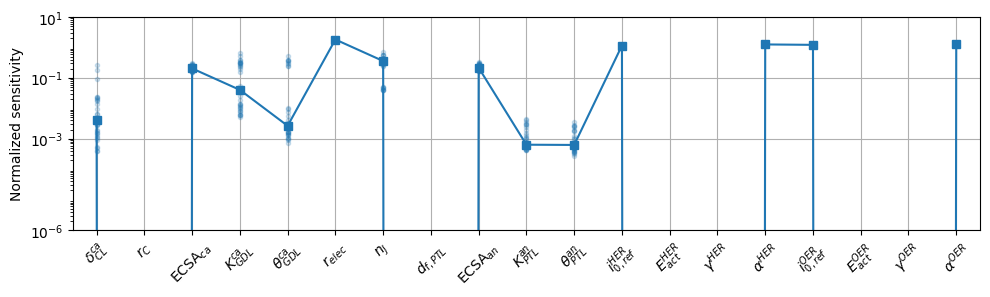

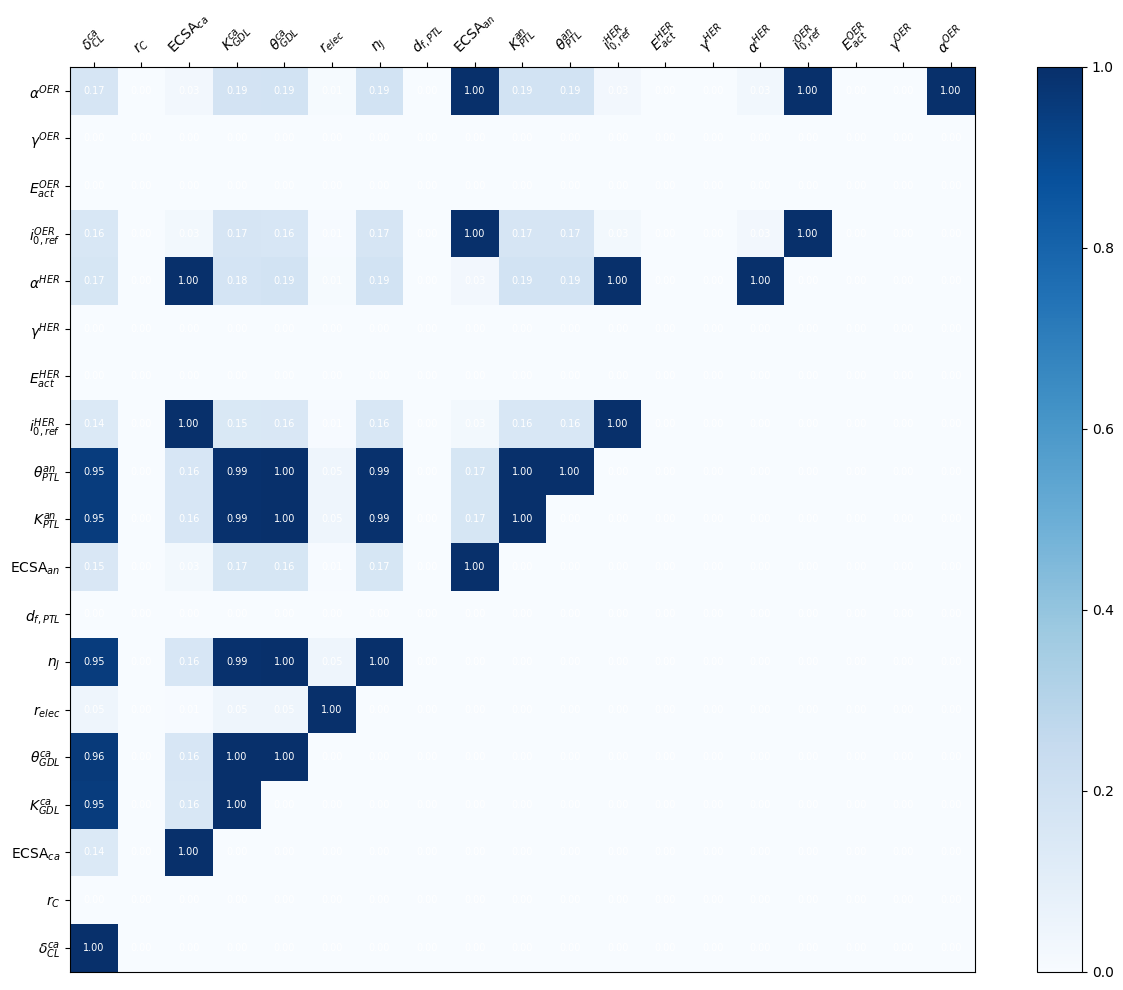

In [70]:
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45,xlabel_ha='center',figsize=(10,3)) 
x1 = ax1.get_xticks()
ax1.set_ylabel('Normalized sensitivity')
ax1.grid()
ax1.set_yticks([1e-6, 1e-3, 0.1, 1e1])


fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(13,10))
for text in ax2.texts: 
    text.set_fontsize(7)
plt.show()

In [67]:
from scipy.linalg import qr, eigvals

def estimate(initial_n, final_n, model, P, n_parameters_folds = [], penalty_threshold=0):
    for n_selected in range(initial_n, final_n+1):
        list_unknown = [model.unknown_p_list[p] for p in P[:n_selected]]
        folds = []
        for nk, k in enumerate(full_case_list): 
            print('-'*20)
            print(f'{nk+1} fold - case {k}')
            print('-'*20)
            k_train_case_list = [case for case in full_case_list if k != case]
            k_model = build_model(k_train_case_list, model.p) 
            k_model.set_unknown_params(list_unknown)
            t0 = time.time()
            k_sol, k_p_est = k_model.estimate(get_cases_exp_data(k_train_case_list), t=0, print_iterations=False, popsize=20, ftol=1e-5, penalty_threshold=penalty_threshold)
            tf = time.time()
            k_model.p.update({param: v for param, v in zip(k_model.p_i_name, k_p_est)})
            folds.append({
                'test_case': k,
                'test_case_list': [k],
                'train_case_list': k_train_case_list, 
                'model': k_model, 
                'sol': k_sol,
                'p_est': k_p_est,
                'time': tf-t0
            })
        average_rmse = np.sum([np.sqrt(fold['sol'].fun)*1e3 for fold in folds]) / len(folds)
        print(f"Number of parameters: {len(list_unknown):d} - Average RMSE: {average_rmse:.2f}")

        n_parameters_folds.append(folds)
    return n_parameters_folds


def get_smallest_eigenvalues(S_med):
    num_parameters = np.shape(S_med)[0]

    S = S_med.copy()
    S = S.transpose()


    Q, R, P = qr(S, mode='economic', pivoting=True)

    min_eigvals = []
    indices = np.arange(num_parameters)
    for i in range(num_parameters):
        selected_indices = indices[np.isin(indices, P[:i+1])]
        H = np.matmul(S_med[selected_indices,:], S_med[selected_indices,:].transpose())
        min_eigvals.append(np.min(eigvals(H)))
    return P, min_eigvals, num_parameters 

def plot_parameter_ranking( S_med, model):

    P, min_eigvals, num_parameters = get_smallest_eigenvalues(S_med)

    fig, ax = plt.subplots(figsize=(12,2.5))
    ax.semilogy(1+np.arange(len(model.unknown_p_list)), np.abs(min_eigvals), '-s')
    ax.set_xticks(1+np.arange(len(model.unknown_p_list)))
    ax.set_xticklabels([model.unknown_p_list[i][-2] for i in P],rotation=45)
    ax2 = ax.twiny()
    ax.set_xlim([0,32])
    ax.set_xlabel('Ranked parameters')
    ax2.set_xticks(1+np.arange(len(model.unknown_p_list)))
    ax2.set_xlim([0,32])
    ax2.set_xlabel('Number of selected parameters')
    ax.grid()
    ax.set_ylabel('Smallest Hessian\neigenvalue')
    fig.tight_layout()
    return P, num_parameters, fig, ax, ax2

/var/folders/q2/mryrbb1x7yz_7_1dzt__d5n8w_l3v1/T/ipykernel_835/4188927852.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(1e-15, 100000.0)

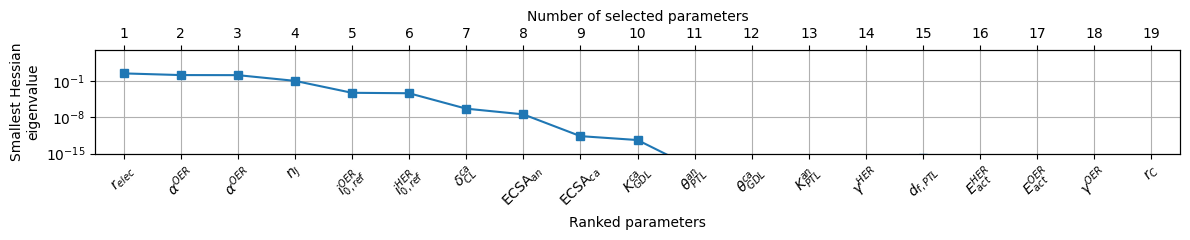

In [68]:
P, num_parameters, fig, ax, ax2 = plot_parameter_ranking(S_med, model)
fig.figsize=(10,6)
fig.show()
ax.set_xlim([0.5,len(model.unknown_p_list) + 0.5])
ax2.set_xlim([0.5,len(model.unknown_p_list) + 0.5])
ax.set_ylim([1e-15,1e5])